In [1]:
import all_samplers
import matplotlib.pyplot as plt
import numpy as np
import importlib as imp
import arviz as az

In [51]:
imp.reload(all_samplers)

<module 'all_samplers' from 'c:\\Users\\benga\\OneDrive\\Desktop\\CAM\\RSCAM\\Group Report\\all_samplers.py'>

In [52]:
config = all_samplers.SamplerConfig()

In [53]:
gammas = np.logspace(-3, -1, 10)  # Example gamma values to test
mses = []
seconds = []
wass = []
samples = []
esss = []
mean_gamma = []
var_gamma = []
for gamma in gammas:
    sample = all_samplers.myula_sampler(gamma, config)
    mses.append(config.mse_first_moment(sample))
    seconds.append(config.mse_second_moment(sample))
    wass.append(config.wassterstein(sample))
    samples.append(sample)
    esss.append(az.ess(sample))
    mean_gamma.append(np.abs(config.true_mean() - all_samplers.true_mean_gamma(gamma, config)))
    var_gamma.append(np.abs(config.true_var() - all_samplers.true_var_gamma(gamma, config)))

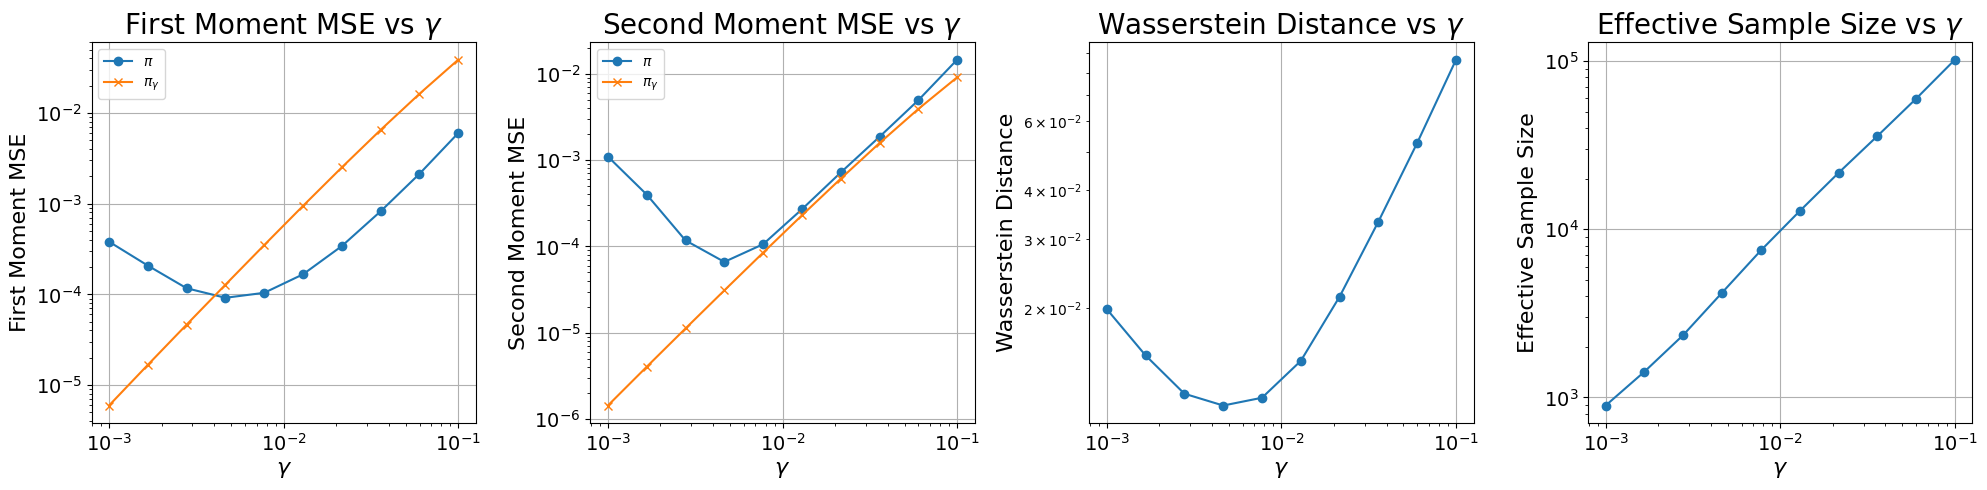

gamma_hat = 4.64e-03


In [54]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].loglog(gammas, mses, marker='o', label=r'$\pi$')
axs[0].loglog(gammas, mean_gamma, marker='x', label=r'$\pi_\gamma$')

axs[1].loglog(gammas, seconds, marker='o', label=r'$\pi$')
axs[1].loglog(gammas, var_gamma, marker='x', label=r'$\pi_\gamma$')

axs[2].loglog(gammas, wass, marker='o')

axs[3].loglog(gammas, esss, marker='o')


tit_strs = ['First Moment MSE', 'Second Moment MSE', 'Wasserstein Distance', 'Effective Sample Size']

for tit_str, ax in zip(tit_strs, axs):
    ax.set_title(tit_str + fr' vs $\gamma$', fontsize=20)
    ax.set_xlabel(r'$\gamma$', fontsize=16)
    ax.set_ylabel(tit_str, fontsize=16)
    ax.grid()
    ax.tick_params(axis='both', which='major', labelsize=14)


# for ax in axs:
    # ax.set_xlabel('gamma')
    # ax.set_xticklabels(np.round(gammas))
    # ax.grid()
    
axs[0].legend()
axs[1].legend()
plt.tight_layout()
plt.savefig('Images/my_ula.pdf', bbox_inches='tight')
plt.show()

ix = np.argmin(wass)
gamma_hat = gammas[ix]
print(f'gamma_hat = {gamma_hat:.2e}')

In [46]:
timesteps = np.logspace(-3, -1, 10) 
mses = []
seconds = []
wass = []
samples = []
esss = []
for h in timesteps:
    sample = all_samplers.hadamard_sampler(h, config)
    mses.append(config.mse_first_moment(sample))
    seconds.append(config.mse_second_moment(sample))
    wass.append(config.wassterstein(sample))
    samples.append(sample)
    esss.append(az.ess(sample))

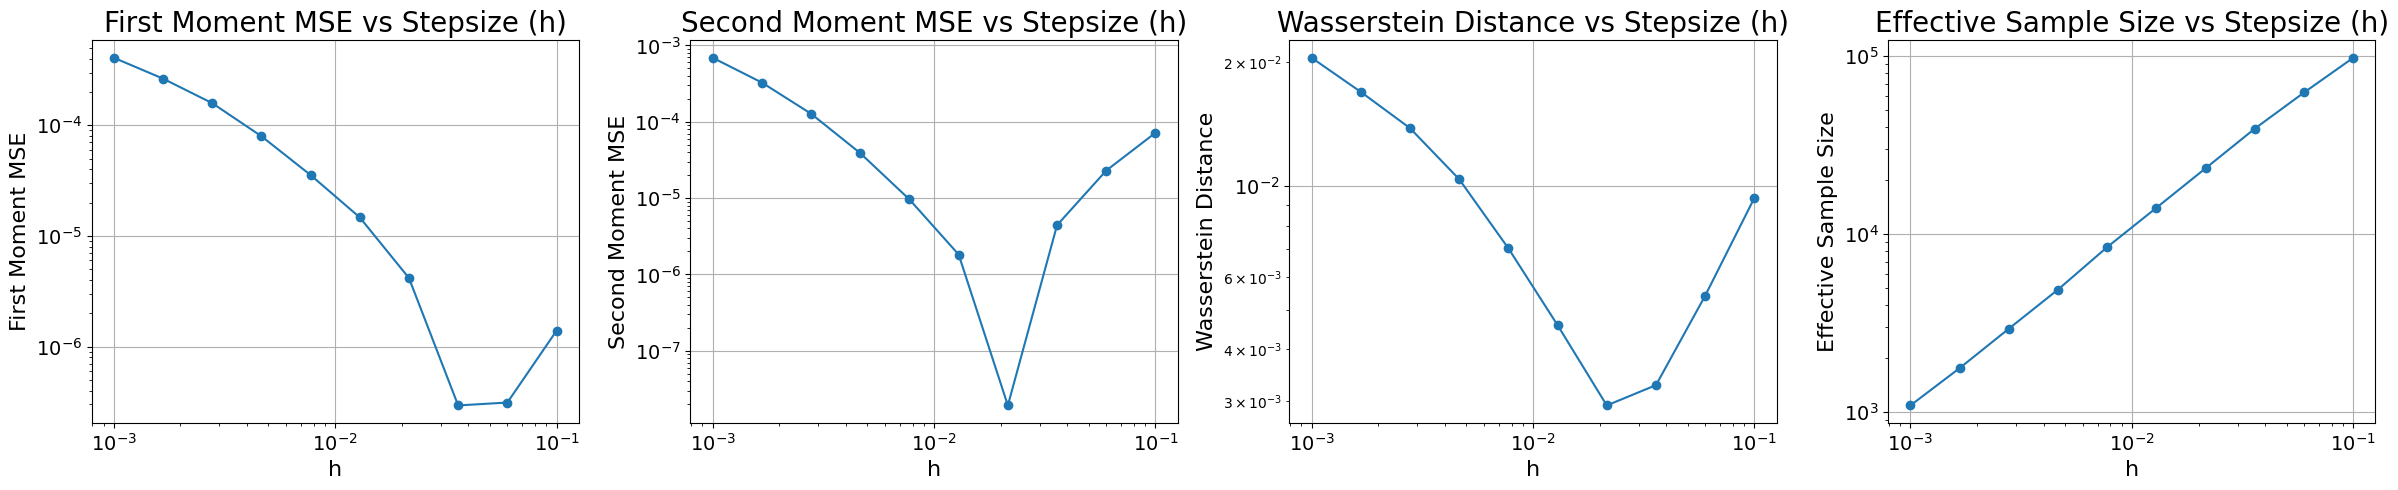

h_hat = 2.15e-02


In [50]:
fig, axs = plt.subplots(1, 4, figsize=(24, 5))

for var, ax in zip([mses, seconds, wass, esss], axs):
    ax.loglog(gammas, var, marker='o')

tit_strs = ['First Moment MSE', 'Second Moment MSE', 'Wasserstein Distance', 'Effective Sample Size']

for tit_str, ax in zip(tit_strs, axs):
    ax.set_title(tit_str + f' vs Stepsize (h)', fontsize=20)
    ax.set_xlabel('h', fontsize=16)
    ax.set_ylabel(tit_str, fontsize=16)
    ax.grid()
    ax.tick_params(axis='both', which='major', labelsize=14)
    
    
plt.tight_layout()
plt.savefig('Images/hadamard.pdf', bbox_inches='tight')
plt.show()

ix = np.argmin(wass)
h_hat = timesteps[ix]
print(f'h_hat = {h_hat:.2e}')

Sampling...
Done Gibbs sampling
Done MYULA sampling
Done Hadamard sampling


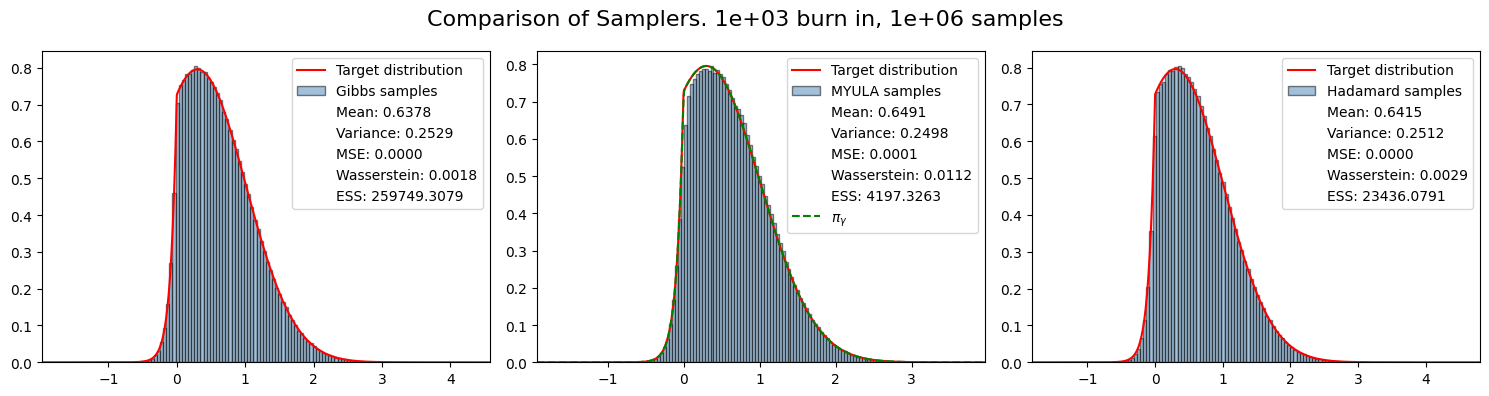

In [48]:
all_samplers.main_all(gamma_hat, h_hat)